---
jupyter:
  jupytext:
    text_representation:
      extension: .qmd
      format_name: quarto
      format_version: '1.0'
      jupytext_version: 1.16.4
  kernelspec:
    display_name: R
    language: R
    name: ir
---

**Data source:** The benchmark combines [DLPFC 10x Visium](https://github.com/LieberInstitute/HumanPilot), [MERFISH hypothalamus](https://datadryad.org/stash/dataset/doi:10.5061/dryad.8t8s248), [STARmap MPFC](https://www.starmapresources.org/data), and Stereo-seq embryo data under CNGBdb accession [CNP0001543](https://db.cngb.org/search/project/CNP0001543/).

# Spatial benchmark summary figure

Aggregation and visualization of accuracy, spatial continuity, and batch-removal metrics across spatial benchmarks.


In [1]:
setwd('./results')

In [37]:
twomethod.data <- read.csv('./agg_metrics.csv', row.names = 1)
step.data <- read.csv('./agg_metrics_step_old-Copy1.csv', row.names = 1)
step.mosta.data <- read.csv('./step_mosta_metrics.csv', row.names = 1)
bass.data <- read.csv('./bass_old_agg_metrics-Copy1.csv', row.names = 1)
precast.data <- read.csv('./precast_old_agg_metrics-Copy1.csv', row.names = 1)
banksy.res <- read.csv('./banksy_agg_metrics.csv', row.names = 1)
graphst.res <- read.csv('./graphst_old_agg_metrics.csv', row.names = 1)
spatialpca.res <- read.csv('./spatialpca_old_agg_metrics.csv', row.names = 1)

library(tidyr)
library(stringr)

banksy.res <- banksy.res %>%
  mutate(batch = basename(batch) %>% str_remove("\\.h5ad$"))

In [39]:
# my_data <- rbind(twomethod.data, step.data, bass.data, precast.data, banksy.res)
# Get all unique column names
all_cols <- unique(c(
  colnames(twomethod.data),
  colnames(step.data),
  colnames(step.mosta.data),
  colnames(bass.data),
  colnames(precast.data),
  colnames(banksy.res),
  colnames(graphst.res)
))

# Function to add missing columns with NA
add_missing_cols <- function(df, all_cols) {
  missing_cols <- setdiff(all_cols, colnames(df))
  if (length(missing_cols) > 0) {
    df[missing_cols] <- "N/A"
  }
  return(df[, all_cols])  # Ensure columns are in same order
}

# Add missing columns to each dataframe and combine
my_data <- rbind(
  add_missing_cols(twomethod.data, all_cols),
  add_missing_cols(step.data, all_cols),
  add_missing_cols(bass.data, all_cols),
  add_missing_cols(precast.data, all_cols),
  add_missing_cols(banksy.res, all_cols),
  add_missing_cols(step.mosta.data, all_cols),
  add_missing_cols(graphst.res, all_cols),
  add_missing_cols(spatialpca.res, all_cols)
)

head(my_data)

,batch,method,dataset,NMI,ARI,CHAOS,PAS,ASW,iLICI
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
0,151507,STAligner,DLPFC P1,0.6521866,0.4803905,0.05663606,0.8712154,0.9204114,0.33449459075927734
1,151508,STAligner,DLPFC P1,0.6474236,0.4807016,0.05611976,0.8727688,0.9204114,0.33449459075927734
2,151509,STAligner,DLPFC P1,0.6674194,0.5111255,0.05429230,0.8585631,0.9204114,0.33449459075927734
3,151510,STAligner,DLPFC P1,0.6287665,0.4684844,0.05616316,0.8576931,0.9204114,0.33449459075927734
4,151669,STAligner,DLPFC P2,0.5830568,0.3374877,0.06246241,0.8630363,0.92120874,0.38143038749694824
5,151670,STAligner,DLPFC P2,0.5464365,0.3367183,0.06213550,0.8584960,0.92120874,0.38143038749694824


In [40]:
write.csv(my_data, "./agg_all_metrics_tmp.csv", quote = FALSE)

In [41]:
summary(my_data)

    batch              method            dataset               NMI         
 Length:171         Length:171         Length:171         Min.   :0.03834  
 Class :character   Class :character   Class :character   1st Qu.:0.47050  
 Mode  :character   Mode  :character   Mode  :character   Median :0.60305  
                                                          Mean   :0.55294  
                                                          3rd Qu.:0.67494  
                                                          Max.   :0.85815  
      ARI               CHAOS               PAS             ASW           
 Min.   :-0.03151   Min.   :0.007194   Min.   :0.3790   Length:171        
 1st Qu.: 0.29696   1st Qu.:0.038824   1st Qu.:0.8094   Class :character  
 Median : 0.45429   Median :0.058778   Median :0.8742   Mode  :character  
 Mean   : 0.43435   Mean   :0.053509   Mean   :0.8236                     
 3rd Qu.: 0.57278   3rd Qu.:0.062142   3rd Qu.:0.9110                     
 Max.   : 0.88336 

In [42]:
library(funkyheatmap)
# library(kableExtra) # Not used in modified section, but kept if you use it elsewhere
library(dplyr)
library(tidyr)


# data("dynbenchmark_data") # From your script, assuming it's used elsewhere or not critical for this part

my_data[my_data == "N/A"] <- as.numeric(NA)
my_data <- as_tibble(my_data)

# Ensure all potential numeric metric columns are converted
potential_metric_cols <- c("NMI", "ARI", "CHAOS", "PAS", "ASW", "iLICI")
for(col_name in potential_metric_cols) {
  if(col_name %in% names(my_data)) {
    my_data[[col_name]] <- suppressWarnings(as.numeric(my_data[[col_name]]))
  }
}


my_data <- my_data %>%
  mutate(batch = case_when(
    # STARmap MPFC replacements
    dataset == "STARmap MPFC" & batch == "0" ~ "20180417_BZ5_control",
    dataset == "STARmap MPFC" & batch == "1" ~ "20180419_BZ9_control",
    dataset == "STARmap MPFC" & batch == "2" ~ "20180424_BZ14_control",
    # MERFISH Hypothalamus - add Bregma prefix
    dataset == "MERFISH Hypothalamus" ~ paste0("Bregma", batch),
    # Keep all other values as is
    TRUE ~ batch
  )) %>%
    mutate(
        CHAOS = -log10(CHAOS) / 2 # User confirms iLICI is already higher-is-better
    )

# my_data <- my_data %>%
#   mutate(batch = case_when(
#     dataset == "STARmap MPFC" ~ strsplit(batch)[[1]][2],
#     TRUE ~ batch
#   ))
agg_metrics <- my_data # As per your script

metrics_order <- c("NMI", "ARI", "CHAOS", "PAS", "ASW", "iLICI")
datasets_order <- sort(unique(agg_metrics$dataset))

# --- MODIFICATION START: agg_metrics_wide calculation ---
accuracy_metric_bases <- c("NMI", "ARI")
continuity_metric_bases <- c("CHAOS", "PAS")
batch_removal_metric_bases <- c("ASW", "iLICI")

num_total_datasets <- length(datasets_order)

total_accuracy_datapoints <- length(accuracy_metric_bases) * num_total_datasets
total_continuity_datapoints <- length(continuity_metric_bases) * num_total_datasets
total_batch_removal_datapoints <- length(batch_removal_metric_bases) * num_total_datasets

agg_metrics_wide <- my_data %>% 
  group_by(method, dataset) %>%
  summarize(
    across(where(is.numeric), mean, na.rm = TRUE), 
    .groups = 'drop'
  ) %>%
  mutate(across(all_of(metrics_order), ~if_else(is.nan(.), NA_real_, .))) %>%
  pivot_wider(
    id_cols = method,
    names_from = dataset,
    values_from = where(is.numeric), 
    names_glue = "{.value}_{dataset}" 
  ) %>%
  {
    all_expected_metric_dataset_cols <- as.vector(outer(metrics_order, datasets_order, paste, sep = "_"))
    # Ensure only existing pivoted columns are selected before mutate, plus method
    select(., method, any_of(all_expected_metric_dataset_cols)) 
  } %>%
  mutate(
    Accuracy_Sum = rowSums(select(., starts_with(paste0(accuracy_metric_bases, "_"))), na.rm = TRUE),
    Accuracy = Accuracy_Sum / total_accuracy_datapoints,

    Continuity_Sum = rowSums(select(., starts_with(paste0(continuity_metric_bases, "_"))), na.rm = TRUE),
    Continuity = Continuity_Sum / total_continuity_datapoints,

    `Batch Removal_Sum` = rowSums(select(., starts_with(paste0(batch_removal_metric_bases, "_"))), na.rm = TRUE),
    `Batch Removal` = `Batch Removal_Sum` / total_batch_removal_datapoints
  ) %>%
  # Select final columns: method, the new overall scores, and all individual metric columns. Remove sums.
  # The `N_*_Run` columns are NOT created or selected.
  select(method, Accuracy, Continuity, `Batch Removal`, everything(), -ends_with("_Sum"))
# --- MODIFICATION END: agg_metrics_wide calculation ---


my_col_info <- tibble(
  id = c(colnames(agg_metrics_wide)), # N_*_Run columns are no longer here
  group = unlist(
    lapply(id, function(x) {
      if (x == 'method') { return(x) }
      if (x %in% c('Accuracy', 'Continuity', 'Batch Removal')) # Only overall scores here
        { return("Overall Scores") }
      y = strsplit(x, '_')[[1]]
      if (length(y) > 1) return(paste(y[2:length(y)], collapse = '_'))
      return(x) 
    })
  ),
  name = unlist(
    lapply(id, function(x) {
      if (x == 'method') { return("") }
      if (x %in% c('Accuracy', 'Continuity', 'Batch Removal')) { return(x) }
      # No N_*_Run names needed
      y = strsplit(x, '_')[[1]]
      return(y[1]) 
    })
  ),
  geom = unlist(
    lapply(id, function(x) {
      if (x == 'method') { return('text') }
      if (x %in% c('Accuracy', 'Continuity', 'Batch Removal')) { return('bar') }
      # No N_*_Run geoms needed
      return('funkyrect')
    })
  ),
  palette = case_when(
    geom == 'text' ~ NA_character_, 
    name == 'Accuracy' ~ 'benchmark',
    name == 'Continuity' ~ 'scaling',
    name == 'Batch Removal' ~ 'stability',
    geom == 'funkyrect' ~ 'benchmark', 
    TRUE ~ 'benchmark' 
  )
)  %>%
  # Simplified arrange, N_*_Run columns are not present
  arrange(match(id, c('method', 'Accuracy', 'Continuity', 'Batch Removal', 
                      setdiff(id, c('method', 'Accuracy', 'Continuity', 'Batch Removal')))))


my_col_groups <- tibble(
  group = unique(my_col_info$group), # Group "Overall Scores" still exists for Accuracy, etc.
  Experiment = case_when(
    group == 'method' ~ 'Method',
    group == 'Overall Scores' ~ 'Summary',
    group == 'DLPFC P1' ~ 'Visium',
    group == 'DLPFC P2' ~ 'Visium',
    group == 'DLPFC P3' ~ 'Visium',
    group == 'MERFISH Hypothalamus' ~ 'MERFISH',
    group == 'STARmap MPFC' ~ 'STARmap',
    group == 'Stereo-seq Mosta' ~ 'Stereo-seq',
    TRUE ~ 'Datasets'
  ),
  Category = case_when(
    group == 'method' ~ '\n',
    group == 'Overall Scores' ~ 'Aggregated scores per aspect',
    group == 'MERFISH Hypothalamus' ~ 'Hypothalamus',
    group == 'STARmap MPFC' ~ 'MPFC',
    group == 'Stereo-seq Mosta' ~ 'Embryo',
    TRUE ~ group
  ),
  palette = case_when(
    group %in% c('method', 'Overall Scores') ~ 'overall',
    Experiment == 'MERFISH' ~ 'scaling',
    Experiment == 'STARmap' ~ 'qc',
    TRUE ~ 'benchmark'
  )
)

agg_metrics_wide[agg_metrics_wide$method == 'MENDER', 'Batch Removal'] = NA 
# No N_Batch_Removal_Run column to set to NA for MENDER

agg_metrics_wide <- agg_metrics_wide %>%
    arrange(desc(Accuracy))


In [43]:
agg_metrics_wide <- agg_metrics_wide %>%
    arrange(desc(Accuracy))

In [44]:
p <- funky_heatmap(agg_metrics_wide, column_info = my_col_info, 
              column_groups = my_col_groups[, c('Experiment', 'Category', 'group', 'palette')], 
              scale_column = F, palettes = dynbenchmark_data$palettes)

ℹ Could not find column 'id' in data. Using rownames as 'id'.

ℹ Column info did not contain a column called 'width', generating options based on the 'geom' column.

ℹ Column info did not contain a column called 'legend', generating options based on the 'geom' column.

ℹ No row info was provided, assuming all rows in `data` are to be plotted.

ℹ Row info did not contain group information, assuming rows are ungrouped.

ℹ No legends were provided, trying to automatically infer legends.

ℹ Some palettes were not used in the column info, adding legends for them.

ℹ Legend 1 did not contain a geom, inferring from the column info.

! Legend 1 has geom 'bar', which is not yet implemented. Disabling for now.

ℹ Legend 2 did not contain a geom, inferring from the column info.

! Legend 2 has geom 'bar', which is not yet implemented. Disabling for now.

ℹ Legend 3 did not contain a geom, inferring from the column info.

! Legend 3 has geom 'bar', which is not yet implemented. Disabling for now.


Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_rect()`).”


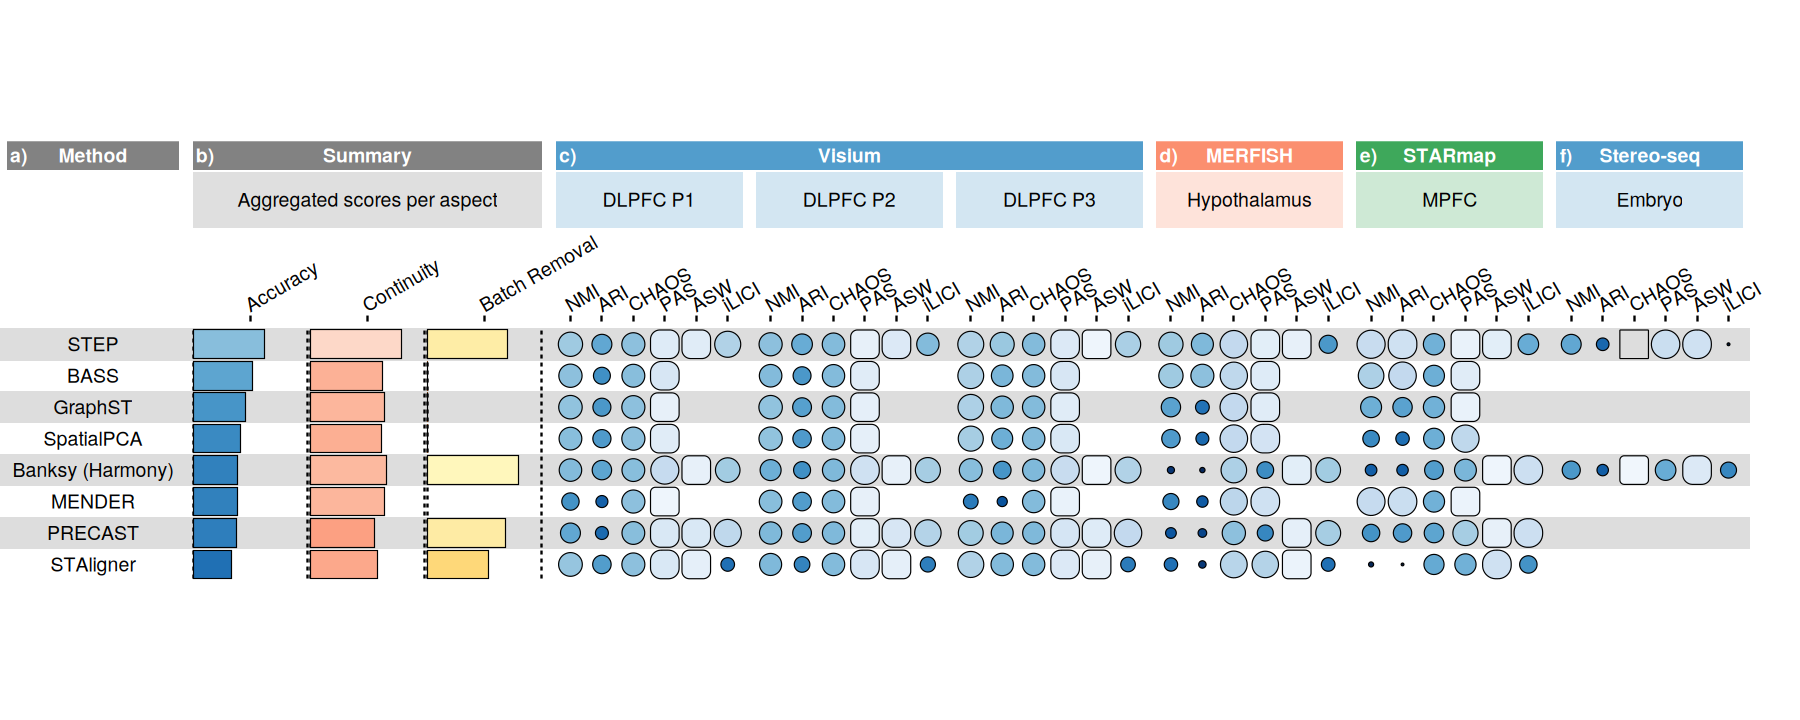

In [47]:
options(repr.plot.width=15, repr.plot.height=6)
plot(p)

In [46]:
library(ggplot2)

ggsave(
  filename = "tmp_metrics.pdf",
  plot = p,
  width = 15,
  height = 4,
  device = "pdf",
  dpi = 300
)

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_rect()`).”
